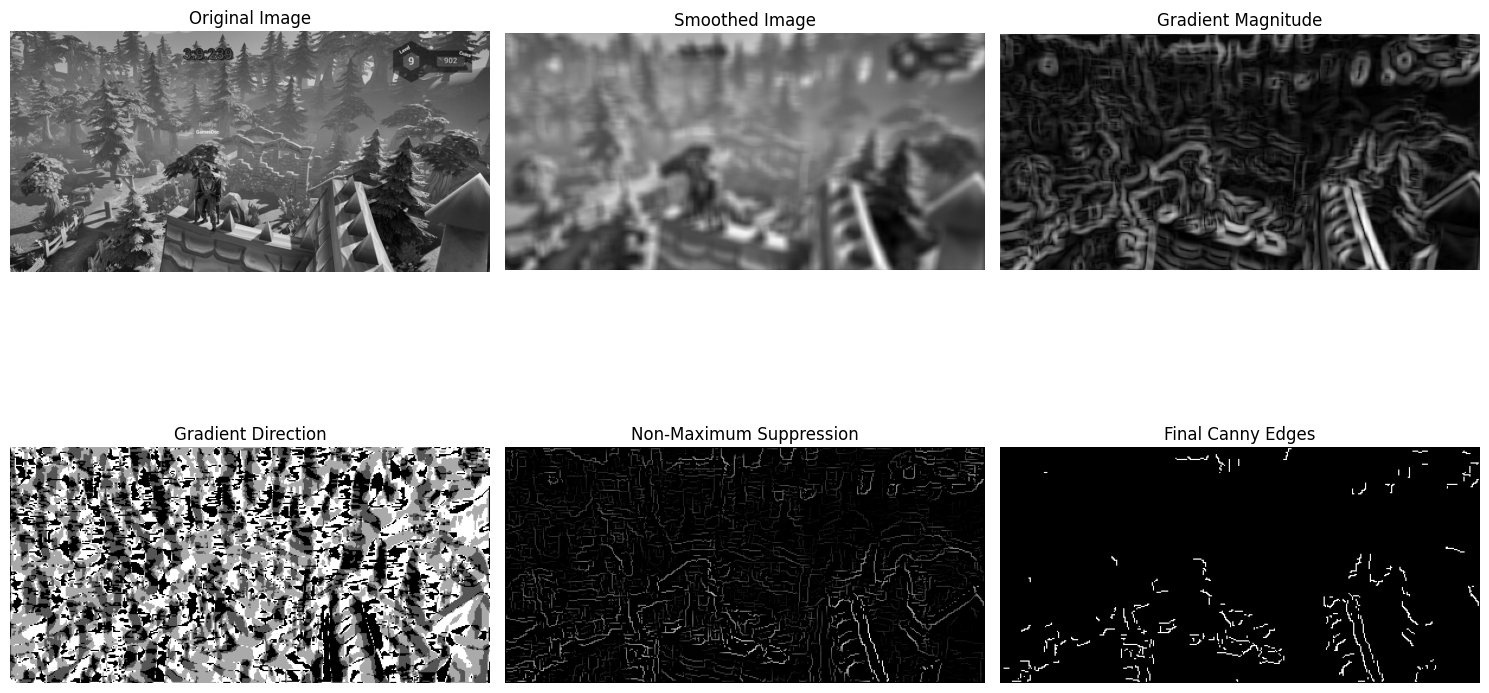

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# ==========================================
# FILTERING FUNCTION
# ==========================================

def filtering(img, kernel, p, s):

    m, n = img.shape
    x, y = kernel.shape

    rows = (m - x + 2 * p) // s + 1
    cols = (n - y + 2 * p) // s + 1

    padded_img = np.pad(
        img,
        p,
        mode='constant',
        constant_values=0
    )

    output = np.zeros((rows, cols))

    for i in range(rows):
        for j in range(cols):
            output[i][j] = np.sum(
                padded_img[
                    i * s:i * s + x,
                    j * s:j * s + y
                ] * kernel
            )

    return output


# ==========================================
# READ IMAGE
# ==========================================

img = cv2.imread("/content/drive/MyDrive/Colab Notebooks/jumptheflooris-cropped.jpg", 0)

if img is None:
    raise ValueError("Image not found. Check the path /content/drive/MyDrive/Colab Notebooks/jumptheflooris-cropped.jpg")


# ==========================================
# SMOOTHING / AVERAGE FILTER
# ==========================================

k = 15
p = 1
s = 2

kernel = np.ones((k, k)) / k**2

filtered_output = filtering(
    img,
    kernel,
    p,
    s
)


# ==========================================
# SOBEL KERNELS
# ==========================================

sobel_kernel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

sobel_kernel_y = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
])


# ==========================================
# SOBEL FILTERING
# ==========================================

filtered_image_x = filtering(
    filtered_output,
    sobel_kernel_x,
    p=0,
    s=1
)

filtered_image_y = filtering(
    filtered_output,
    sobel_kernel_y,
    p=0,
    s=1
)


# ==========================================
# GRADIENT MAGNITUDE
# ==========================================

mag_filtered_image = np.sqrt(
    filtered_image_x ** 2 +
    filtered_image_y ** 2
)


# ==========================================
# GRADIENT ANGLE
# ==========================================

angle_filtered_image = np.degrees(
    np.arctan2(
        filtered_image_y,
        filtered_image_x
    )
)


# ==========================================
# ANGLE QUANTIZATION
# ==========================================

for i in range(angle_filtered_image.shape[0]):

    for j in range(angle_filtered_image.shape[1]):

        angle = angle_filtered_image[i][j]

        if -22.5 <= angle < 22.5:
            angle_filtered_image[i][j] = 0

        elif 22.5 <= angle < 67.5:
            angle_filtered_image[i][j] = 45

        elif 67.5 <= angle < 112.5:
            angle_filtered_image[i][j] = 90

        elif 112.5 <= angle < 157.5:
            angle_filtered_image[i][j] = 135

        elif angle >= 157.5 or angle < -157.5:
            angle_filtered_image[i][j] = 0

        elif -157.5 <= angle < -112.5:
            angle_filtered_image[i][j] = 135

        elif -112.5 <= angle < -67.5:
            angle_filtered_image[i][j] = 90

        elif -67.5 <= angle < -22.5:
            angle_filtered_image[i][j] = 45


# ==========================================
# NON-MAXIMUM SUPPRESSION
# ==========================================

nms = np.zeros_like(mag_filtered_image)

rows, cols = mag_filtered_image.shape

for i in range(1, rows - 1):

    for j in range(1, cols - 1):

        angle = angle_filtered_image[i][j]
        current = mag_filtered_image[i][j]

        # 0 degree
        if angle == 0:

            p1 = mag_filtered_image[i][j - 1]
            p2 = mag_filtered_image[i][j + 1]

        # 45 degree
        elif angle == 45:

            p1 = mag_filtered_image[i - 1][j + 1]
            p2 = mag_filtered_image[i + 1][j - 1]

        # 90 degree
        elif angle == 90:

            p1 = mag_filtered_image[i - 1][j]
            p2 = mag_filtered_image[i + 1][j]

        # 135 degree
        else:

            p1 = mag_filtered_image[i - 1][j - 1]
            p2 = mag_filtered_image[i + 1][j + 1]

        if current >= p1 and current >= p2:
            nms[i][j] = current

        else:
            nms[i][j] = 0


# ==========================================
# DOUBLE THRESHOLD
# ==========================================

T_low = 50
T_high = 100

strong_edges = np.zeros_like(nms)
weak_edges = np.zeros_like(nms)

strong_edges[nms >= T_high] = 255

weak_edges[
    (nms >= T_low) &
    (nms < T_high)
] = 75


# ==========================================
# EDGE TRACKING BY HYSTERESIS
# ==========================================

final_edges = strong_edges.copy()

rows, cols = weak_edges.shape

for i in range(1, rows - 1):

    for j in range(1, cols - 1):

        if weak_edges[i][j] == 75:

            neighbourhood = strong_edges[
                i - 1:i + 2,
                j - 1:j + 2
            ]

            if np.any(neighbourhood == 255):
                final_edges[i][j] = 255

            else:
                final_edges[i][j] = 0


# ==========================================
# DISPLAY RESULTS
# ==========================================

plt.figure(figsize=(15, 10))


# Original
plt.subplot(2, 3, 1)

plt.imshow(img, cmap='gray')

plt.title("Original Image")

plt.axis("off")


# Smoothed
plt.subplot(2, 3, 2)

plt.imshow(filtered_output, cmap='gray')

plt.title("Smoothed Image")

plt.axis("off")


# Gradient Magnitude
plt.subplot(2, 3, 3)

plt.imshow(mag_filtered_image, cmap='gray')

plt.title("Gradient Magnitude")

plt.axis("off")


# Gradient Direction
plt.subplot(2, 3, 4)

plt.imshow(angle_filtered_image, cmap='gray')

plt.title("Gradient Direction")

plt.axis("off")


# Non-Maximum Suppression
plt.subplot(2, 3, 5)

plt.imshow(nms, cmap='gray')

plt.title("Non-Maximum Suppression")

plt.axis("off")


# Final Canny Edges
plt.subplot(2, 3, 6)

plt.imshow(final_edges, cmap='gray')

plt.title("Final Canny Edges")

plt.axis("off")


plt.tight_layout()

plt.show()